<a href="https://colab.research.google.com/github/Skaims/DLAV/blob/main/DLAV_Phase1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DLAV Project - Phase 1

In this notebook we will train a very simple planner on data coming from a driving simulator. You are given a dash cam image of the current state of the driving vehicle, and the past positions of this vehicle, and you are asked to plan its future route.

This notebook will take you through steps on building this planner to solve the task. The full skeleton of the code together with some very simple implementations of each module are provided for your comfort. So all the cells below will run without you needing to change anything, but the performance won't be very good. You are asked to re-implement and play with most of the modules yourself to be able to have better performance.

P.S. to enable fast compute, you should use GPUs in google colab. The code works without GPUs, but it'll be much faster to use GPUs, specially if your model gets bigger and bigger! You can utilize Colab's GPUs by selecting "Change runtime type" in the Runtime menu on top of this page. There you can select "T4 GPU". This would restart your runtime, so you'll need to re-run everything from the top.

The first step is to prepare the data. The code below will download the data from google drive and extract it here for your code to use. Whenever your session gets restarted, remember to re-run this cell to re-download the data.

In [1]:
# Install gdown to handle Google Drive file download
!pip install -q gdown

import gdown
import zipfile

download_url = f"https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr"
output_zip = "dlav_train.zip"
gdown.download(download_url, output_zip, quiet=False)  # Downloads the file to your drive
with zipfile.ZipFile(output_zip, 'r') as zip_ref:  # Extracts the downloaded zip file
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu"
output_zip = "dlav_val.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

download_url = "https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV"
output_zip = "dlav_test_public.zip"
gdown.download(download_url, output_zip, quiet=False)
with zipfile.ZipFile(output_zip, 'r') as zip_ref:
    zip_ref.extractall(".")

Downloading...
From (original): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr
From (redirected): https://drive.google.com/uc?id=1YkGwaxBKNiYL2nq--cB6WMmYGzRmRKVr&confirm=t&uuid=ad85f4b5-7dd0-4734-9e7b-dc5e1b7d8cfc
To: /content/dlav_train.zip
100%|██████████| 439M/439M [00:06<00:00, 64.4MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu
From (redirected): https://drive.google.com/uc?id=1wtmT_vH9mMUNOwrNOMFP6WFw6e8rbOdu&confirm=t&uuid=15d42967-d704-4c5d-8c9b-2f1dcd7708cd
To: /content/dlav_val.zip
100%|██████████| 87.8M/87.8M [00:01<00:00, 45.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV
From (redirected): https://drive.google.com/uc?id=1G9xGE7s-Ikvvc2-LZTUyuzhWAlNdLTLV&confirm=t&uuid=d21e3477-a8bf-438f-815d-d16fcd335a11
To: /content/dlav_test_public.zip
100%|██████████| 86.6M/86.6M [00:01<00:00, 48.4MB/s]


Now lets load the data and visualize the first few examples to see what we are dealing with!

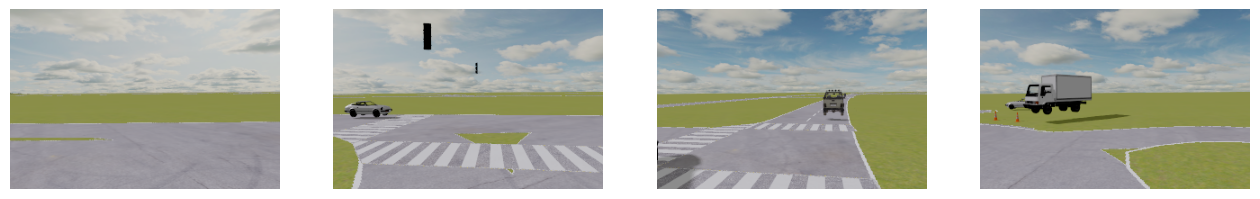

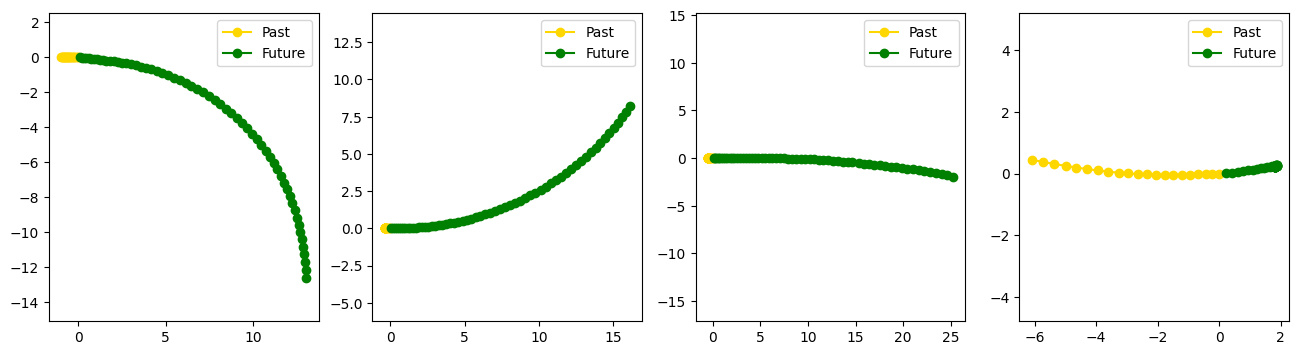

In [2]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import random

k = 4
# load the data
data = []
for i in random.choices(np.arange(1000), k=k):
    with open(f"train/{i}.pkl", "rb") as f:
        data.append(pickle.load(f))

# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].imshow(data[i]["camera"])
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i in range(k):
    axis[i].plot(data[i]["sdc_history_feature"][:, 0], data[i]["sdc_history_feature"][:, 1], "o-", color="gold", label="Past")
    axis[i].plot(data[i]["sdc_future_feature"][:, 0], data[i]["sdc_future_feature"][:, 1], "o-", color="green", label="Future")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now its time to make our hands dirty!

In the following cells we will define the classes we need to do a proper training in pytorch.

1. We will start with defining a Dataset class which loads the data and does some basic preprocessing. You can further process this data as you see fit.
2. We then define the logger which receives training metrics and logs and prints/visualizes them. Having a good logger means a lot when dealing with neural network training! The logger implemented here is very simple and we strongly suggest you try other ways of visualizing your losses and metrics. Be creative ;)
3. We then proceed with defining the core part of the pipeline, the model. You are going to mainly implement the model yourself, but we have provided a very simple model so that the code runs as is so that you can see how the whole framework runs all in all.
4. Finally, we define the training funciton which contains the training loop, and we call it to see the magic! You'll need to also do a lot of changes here, from the batch size and learning rate, to adding augmentation schemes and schedulers, etc.

In [30]:
import torch
import pickle
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import os

class DrivingDataset(Dataset):
    def __init__(self, file_list, test=False, augment=False):
        self.samples = file_list
        self.test = test
        self.augment = augment

        # map string command to id
        self.cmd_map = {'forward': 0, 'left': 1, 'right': 2}

        # image augmentations (used only if augment=True and not test)
        self.img_transform = T.Compose([
            T.ConvertImageDtype(torch.float32),
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.RandomResizedCrop((200, 300), scale=(0.9, 1.0)),
            T.RandomHorizontalFlip(p=0.5),
        ])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        with open(self.samples[idx], "rb") as f:
            data = pickle.load(f)

        # camera: (H,W,3) -> (3,H,W)
        camera = torch.from_numpy(data['camera']).permute(2, 0, 1)  # uint8

        if self.augment and not self.test:
            camera = self.img_transform(camera) * 255.0
        else:
            camera = camera.float()

        # history and future: (T,3)
        history = torch.tensor(data['sdc_history_feature'], dtype=torch.float32)
        future  = torch.tensor(data['sdc_future_feature'],  dtype=torch.float32)

        # compute last_pos from history (no need to be in the pkl)
        last_pos = history[-1, :2].clone()    # (2,)

        # center x,y around last_pos
        history[:, :2] -= last_pos
        future[:,  :2] -= last_pos

        # command
        cmd_str = data['driving_command']
        command = torch.tensor(self.cmd_map[cmd_str], dtype=torch.long)

        if not self.test:
            # train / val case
            return {
                'camera': camera,
                'history': history,   # centered
                'future': future,     # centered
                'command': command,
                'last_pos': last_pos, # for reconstruction in metrics
            }
        else:
            # test case (no future)
            return {
                'camera': camera,
                'history': history,
                'command': command,
                'last_pos': last_pos,
            }




In [3]:
'''
class Logger:
    def __init__(self):
        # Placeholder for potential future configs (e.g., log_dir, wandb_enabled, etc.)
        pass

    def log(self, step=None, **metrics):
        """
        Logs the given metrics.

        Args:
            step (int, optional): The current step or epoch. Useful for tracking.
            **metrics: Arbitrary keyword arguments representing metric names and values.
        """
        prefix = f"[Step {step}] " if step is not None else ""
        metric_str = " | ".join(f"{k}: {v}" for k, v in metrics.items())
        # print(prefix + metric_str)
'''
class Logger:
    def __init__(self):
        self.history = {}

    def log(self, step=None, **metrics):
        for k, v in metrics.items():
            self.history.setdefault(k, []).append((step, float(v)))

    def plot(self):
        for k, vals in self.history.items():
            steps, ys = zip(*vals)
            plt.figure()
            plt.plot(steps, ys)
            plt.title(k)
            plt.xlabel("step")
            plt.ylabel(k)
            plt.show()

In [41]:
import torch
import torch.nn as nn
import torchvision.models as models

class DrivingPlanner(nn.Module):
    def __init__(self, output_dim=256):
        super().__init__()

        # Progressive downsampling with increasing channels
        self.conv1 = self._make_conv_block(3, 64, stride=2)      # 200x300 -> 100x150
        self.conv2 = self._make_conv_block(64, 128, stride=2)    # 100x150 -> 50x75
        self.conv3 = self._make_conv_block(128, 256, stride=2)   # 50x75 -> 25x38
        self.conv4 = self._make_conv_block(256, 512, stride=2)   # 25x38 -> 13x19
        self.conv5 = self._make_conv_block(512, 512, stride=2)   # 13x19 -> 7x10

        # Global average pooling + projection
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.projector = nn.Sequential(
            nn.Linear(512, output_dim),
            nn.ReLU(),
            nn.LayerNorm(output_dim),
            nn.Dropout(0.1)
        )

    def _make_conv_block(self, in_channels, out_channels, stride=1):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3,
                     stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3,
                     padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # Normalize to [0, 1]
        x = x / 255.0

        x = self.conv1(x)
        x = self.conv2(x)

In [42]:
import torch
import torch.nn as nn
import torchvision.models as models


class ResNetPlanner(nn.Module):
    def __init__(self, future_len=60, hidden_dim=128, cmd_dim=16):
        super().__init__()
        backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)
        self.cnn = nn.Sequential(*list(backbone.children())[:-1])
        img_dim = backbone.fc.in_features  # 512


        self.history_encoder = nn.LSTM(
            input_size=3,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            dropout=0.3
        )

        self.cmd_embed = nn.Embedding(3, cmd_dim)

        fusion_dim = img_dim + 64 + cmd_dim
        self.decoder = nn.Sequential(
            nn.Linear(fusion_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(hidden_dim, future_len * 2),
        )
        self.future_len = future_len

    def forward(self, image, history, command):
        img_feat = self.cnn(image).flatten(1)
        _, (h_n, _) = self.history_encoder(history)
        hist_feat = h_n[-1]
        cmd_feat = self.cmd_embed(command)

        fused = torch.cat([img_feat, hist_feat, cmd_feat], dim=1)
        pred = self.decoder(fused).view(-1, self.future_len, 2)
        return pred   # normalized coordinates



In [43]:
import torch
import numpy as np

huber = nn.SmoothL1Loss(beta=1.0)

def ade_loss(pred, target):
    return huber(pred[..., :2], target[..., :2])

def normalize_image(image, device):
    image = image / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
    return (image - mean) / std



def train(model, train_loader, val_loader, optimizer, scheduler, num_epochs=50, patience=5):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    best_ade = float('inf')
    best_state = None
    no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            image   = batch['camera'].to(device)
            history = batch['history'].to(device)      # normalized
            future  = batch['future'].to(device)       # normalized
            command = batch['command'].to(device)
            last_pos = batch['last_pos'].to(device)    # (B,2)

            image = normalize_image(image, device)

            optimizer.zero_grad()
            pred_norm = model(image, history, command)  # (B,60,2) normalized

            loss = ade_loss(pred_norm, future)          # ADE in normalized frame
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        # ---------- VAL ----------
        model.eval()
        ade_all, fde_all = [], []
        with torch.no_grad():
          for batch in val_loader:
              image   = batch['camera'].to(device)
              history = batch['history'].to(device)
              future  = batch['future'].to(device)        # (B,60,3), centered
              command = batch['command'].to(device)
              last_pos = batch['last_pos'].to(device)     # (B,2)

              image = normalize_image(image, device)

              pred_norm = model(image, history, command)  # (B,60,2), centered

              # back to original frame for metrics (x,y only)
              pred_world_xy   = pred_norm + last_pos[:, None, :]      # (B,60,2)
              future_world_xy = future[..., :2] + last_pos[:, None, :]# (B,60,2)

              diff = pred_world_xy - future_world_xy
              ADE = torch.norm(diff, dim=-1).mean()
              FDE = torch.norm(diff[:, -1, :], dim=-1).mean()

              ade_all.append(ADE.item())
              fde_all.append(FDE.item())


        mean_train = train_loss / len(train_loader)
        mean_ade   = float(np.mean(ade_all))
        mean_fde   = float(np.mean(fde_all))

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {mean_train:.4f} | ADE: {mean_ade:.4f} | FDE: {mean_fde:.4f}")


In [44]:
# ============================================
# DATALOADERS
# ============================================
train_data_dir = "train"
val_data_dir   = "val"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
val_files   = [os.path.join(val_data_dir,   f) for f in os.listdir(val_data_dir)   if f.endswith('.pkl')]

train_dataset = DrivingDataset(train_files, augment=False)
val_dataset   = DrivingDataset(val_files,   augment=False)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, num_workers=2)

# ============================================
# MODEL
# ============================================
model = ResNetPlanner(future_len=60, hidden_dim=128)

# ============================================
# PHASE 1 – TRAIN WITH FROZEN BACKBONE
# ============================================
print("=== Phase 1: training with frozen ResNet backbone ===")

for p in model.cnn.parameters():
    p.requires_grad = False

optimizer1 = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=3e-4,
    weight_decay=1e-4
)
scheduler1 = torch.optim.lr_scheduler.StepLR(optimizer1, step_size=10, gamma=0.5)

train(
    model,
    train_loader,
    val_loader,
    optimizer1,
    scheduler1,
    num_epochs=30,   # fewer epochs for phase 1
    patience=5
)

# ============================================
# PHASE 2 – UNFREEZE BACKBONE AND FINE-TUNE
# ============================================
print("\n=== Phase 2: unfreezing ResNet backbone and fine-tuning ===")

for p in model.cnn.parameters():
    p.requires_grad = True

optimizer2 = optim.Adam(
    model.parameters(),
    lr=1e-4,          # smaller LR for fine-tuning
    weight_decay=1e-4
)
scheduler2 = torch.optim.lr_scheduler.StepLR(optimizer2, step_size=10, gamma=0.5)

train(
    model,
    train_loader,
    val_loader,
    optimizer2,
    scheduler2,
    num_epochs=20,    # shorter fine-tuning
    patience=5
)

=== Phase 1: training with frozen ResNet backbone ===


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch 1/30 | Train Loss: 5.5688 | ADE: 5.3481 | FDE: 13.7685
Epoch 2/30 | Train Loss: 2.6265 | ADE: 3.7403 | FDE: 9.3138
Epoch 3/30 | Train Loss: 2.2484 | ADE: 4.3458 | FDE: 10.3131
Epoch 4/30 | Train Loss: 2.0719 | ADE: 3.2779 | FDE: 8.4072
Epoch 5/30 | Train Loss: 1.8863 | ADE: 2.9601 | FDE: 7.6905
Epoch 6/30 | Train Loss: 1.8054 | ADE: 2.8438 | FDE: 7.4258
Epoch 7/30 | Train Loss: 1.7613 | ADE: 2.7952 | FDE: 7.3325
Epoch 8/30 | Train Loss: 1.7242 | ADE: 2.7613 | FDE: 7.1591
Epoch 9/30 | Train Loss: 1.6754 | ADE: 3.0593 | FDE: 7.7307
Epoch 10/30 | Train Loss: 1.7278 | ADE: 2.8898 | FDE: 7.4143
Epoch 11/30 | Train Loss: 1.6168 | ADE: 2.6969 | FDE: 7.1615
Epoch 12/30 | Train Loss: 1.5668 | ADE: 2.6621 | FDE: 7.1139
Epoch 13/30 | Train Loss: 1.5651 | ADE: 2.6101 | FDE: 7.0092
Epoch 14/30 | Train Loss: 1.5456 | ADE: 2.7813 | FDE: 7.3180
Epoch 15/30 | Train Loss: 1.5568 | ADE: 2.6654 | FDE: 7.0088
Epoch 16/30 | Train Loss: 1.5392 | ADE: 2.7069 | FDE: 7.1369
Epoch 17/30 | Train Loss: 1.522

In [6]:
import torch
import pickle
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
import os

class DrivingDataset2(Dataset):
    def __init__(self, file_list, test=False):
        self.samples = file_list
        self.test = test
        self.cmd_map = {'forward': 0, 'left': 1, 'right': 2}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        with open(self.samples[idx], 'rb') as f:
            data = pickle.load(f)

        camera  = torch.FloatTensor(data['camera']).permute(2, 0, 1)   # (3, 200, 300)
        history = torch.FloatTensor(data['sdc_history_feature'])       # (21, 3)
        cmd_str = data['driving_command']
        cmd_id  = self.cmd_map[cmd_str]
        command = torch.tensor(cmd_id, dtype=torch.long)

        if not self.test:
            future = torch.FloatTensor(data['sdc_future_feature'])     # (60, 3)
            return {
                'camera': camera,
                'history': history,
                'command': command,
                'future': future
            }
        else:
            return {
                'camera': camera,
                'history': history,
                'command': command
            }


In [7]:
import torch
import torch.nn as nn
import torchvision.models as models

class PretrainedResNetPlannerCMD(nn.Module):
    def __init__(self,
                 num_cmds=3,
                 history_steps=21,
                 future_steps=60,
                 history_dim=3,
                 future_dim=3,
                 backbone_name='resnet18',
                 backbone_pretrained=True,
                 history_hidden=128,
                 fused_dim=256,
                 dropout=0.2):
        super().__init__()
        self.future_steps = future_steps
        self.future_dim   = future_dim

        # --- Image backbone ---
        backbone = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1 if backbone_pretrained else None
        )
        backbone_out_dim = backbone.fc.in_features
        self.backbone = nn.Sequential(*list(backbone.children())[:-1])  # (B, C, 1, 1)
        self.img_proj = nn.Sequential(
            nn.Linear(backbone_out_dim, fused_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        # --- History encoder ---
        self.history_gru = nn.GRU(
            input_size=history_dim,
            hidden_size=history_hidden,
            num_layers=2,
            batch_first=True,
            dropout=dropout,
            bidirectional=True,
        )
        self.hist_proj = nn.Sequential(
            nn.Linear(history_hidden * 2, fused_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        # --- Command encoder ---
        self.cmd_emb = nn.Embedding(num_cmds, 32)
        self.cmd_proj = nn.Sequential(
            nn.Linear(32, fused_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )

        # --- Fusion + decoder ---
        self.fusion = nn.Sequential(
            nn.Linear(fused_dim * 3, fused_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fused_dim, fused_dim),
            nn.ReLU(inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.Linear(fused_dim, fused_dim * 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fused_dim * 2, future_steps * future_dim),
        )

        # ImageNet normalization
        self.register_buffer(
            "img_mean",
            torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1),
            persistent=False,
        )
        self.register_buffer(
            "img_std",
            torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1),
            persistent=False,
        )

    def encode_image(self, camera):
        x = camera / 255.0
        x = (x - self.img_mean) / self.img_std
        x = self.backbone(x)              # (B, C, 1, 1)
        x = x.view(x.size(0), -1)         # (B, C)
        return self.img_proj(x)           # (B, fused_dim)

    def encode_history(self, history):
        out, _ = self.history_gru(history)
        last = out[:, -1, :]              # (B, 2*hidden)
        return self.hist_proj(last)       # (B, fused_dim)

    def encode_command(self, command):
        # command: (B,) long
        emb = self.cmd_emb(command)       # (B, 32)
        return self.cmd_proj(emb)         # (B, fused_dim)

    def forward(self, camera, history, command):
        img_feat  = self.encode_image(camera)
        hist_feat = self.encode_history(history)
        cmd_feat  = self.encode_command(command)

        fused = torch.cat([img_feat, hist_feat, cmd_feat], dim=1)  # (B, 3*fused_dim)
        fused = self.fusion(fused)
              # (B, fused_dim)

        out = self.decoder(fused)                                  # (B, 60*3)
        return out.view(-1, self.future_steps, self.future_dim)


In [8]:
def train2(model, train_loader, val_loader, optimizer, logger, num_epochs=50):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)

    criterion = nn.MSELoss()

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            image   = batch['camera'].to(device)
            history = batch['history'].to(device)      # normalized
            future  = batch['future'].to(device)       # normalized
            command = batch['command'].to(device)


            optimizer.zero_grad()
            pred_future = model(image, history, command)  # (B,60,2) normalized

            loss = criterion(pred_future[..., :2], future[..., :2])
            optimizer.step()
            train_loss += loss.item()

        # ---------- VAL ----------
        model.eval()
        ade_all, fde_all = [], []
        with torch.no_grad():
          for batch in val_loader:
              image   = batch['camera'].to(device)
              history = batch['history'].to(device)
              future  = batch['future'].to(device)        # (B,60,3), centered
              command = batch['command'].to(device)


              pred_future = model(image, history, command)  # (B,60,2), centered

              ADE = torch.norm(pred_future[:, :, :2] - future[:, :, :2], p=2, dim=-1).mean()
              FDE = torch.norm(pred_future[:, -1, :2] - future[:, -1, :2], p=2, dim=-1).mean()

              ade_all.append(ADE.item())
              fde_all.append(FDE.item())


        mean_train = train_loss / len(train_loader)
        mean_ade   = float(np.mean(ade_all))
        mean_fde   = float(np.mean(fde_all))

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {mean_train:.4f} | ADE: {mean_ade:.4f} | FDE: {mean_fde:.4f}")

In [9]:
train_data_dir = "train"
val_data_dir   = "val"

train_files = [os.path.join(train_data_dir, f) for f in os.listdir(train_data_dir) if f.endswith('.pkl')]
val_files   = [os.path.join(val_data_dir,   f) for f in os.listdir(val_data_dir)   if f.endswith('.pkl')]

train_dataset = DrivingDataset2(train_files)
val_dataset   = DrivingDataset2(val_files)

train_loader = DataLoader(train_dataset, batch_size=32, num_workers=2, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, num_workers=2)

model = PretrainedResNetPlannerCMD(
    history_steps=21,
    future_steps=60,
    backbone_name='resnet18',
    backbone_pretrained=True,
    fused_dim=256
)

optimizer = optim.Adam(model.parameters(), lr=1e-3)
logger = Logger()

train2(model, train_loader, val_loader, optimizer, logger, num_epochs=50)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 94.4MB/s]


KeyboardInterrupt: 

By running the code above, you have trained your first model!
What do you observe in terms of train and val losses? What is this phenomenon called? (Explain in a few lines below)




This model is very simple and does not necessarilly yield the optimal performance. You are asked to implement your own neural network architecture. You can use convolution networks, vision transformers, etc. Try with different architectures, different model sizes, and other hyper parameters such as learning rate and batch size to find the best performance. Other ideas could be to use augmentation thechniques to boost the performance, adding learning rate schedulers, and exploring other loss functions.

Once you are happy with your model, continue with the rest of the notebook to save your checkpoint and also visualize some plans coming from the model. The last cell will provide a `submission_phase1.csv` which you can submit to the leaderboard to see your results on the testing set.

In [ ]:
# save the model
torch.save(model.state_dict(), "phase6_pretrained_RestNet.pth")

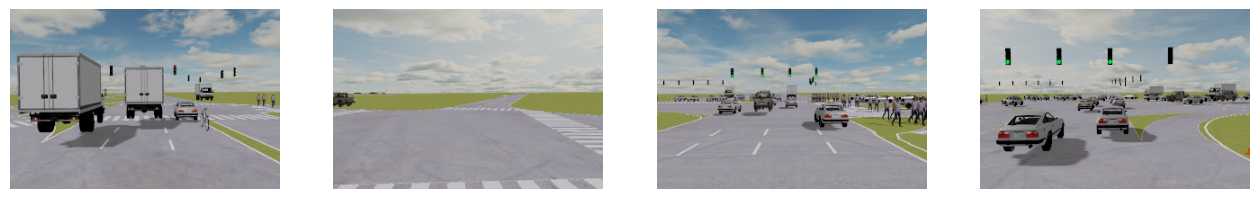

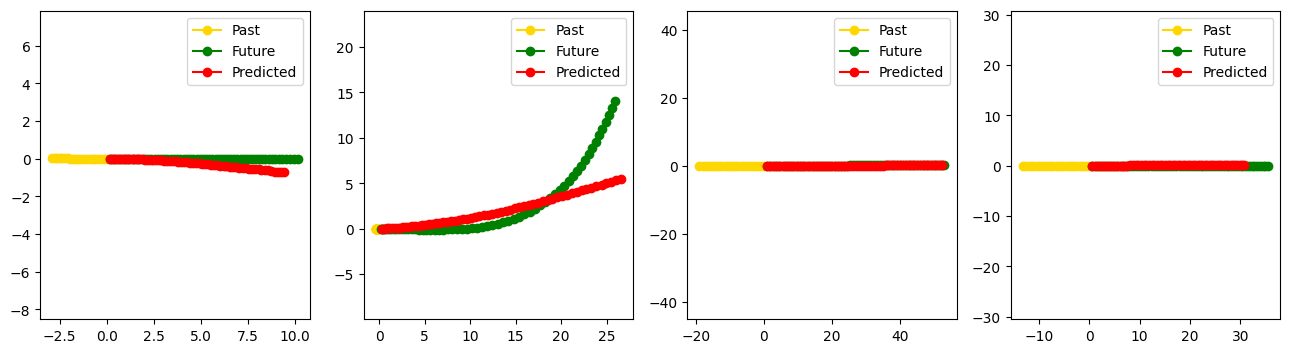

In [ ]:
val_batch_zero = next(iter(val_loader))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
camera = val_batch_zero['camera'].to(device)
history = val_batch_zero['history'].to(device)
command = val_batch_zero['command'].to(device)
future = val_batch_zero['future'].to(device)

model.eval()
with torch.no_grad():
    pred_future = model(camera, history, command)

camera = camera.cpu().numpy()
history = history.cpu().numpy()
future = future.cpu().numpy()
pred_future = pred_future.cpu().numpy()
k=4
selected_indices = random.choices(np.arange(len(camera)), k=k)
# plot the camera view of current step for the k examples
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].imshow(camera[idx].transpose(1, 2, 0)/255)
    axis[i].axis("off")
plt.show()

# plot the past and future trajectory of the vehicle
fig, axis = plt.subplots(1, k, figsize=(4*k, 4))
for i, idx in enumerate(selected_indices):
    axis[i].plot(history[idx, :, 0], history[idx, :, 1], "o-", color="gold", label="Past")
    axis[i].plot(future[idx, :, 0], future[idx, :, 1], "o-", color="green", label="Future")
    axis[i].plot(pred_future[idx, :, 0], pred_future[idx, :, 1], "o-", color="red", label="Predicted")
    axis[i].legend()
    axis[i].axis("equal")
plt.show()

Now we run our model on the test set once, to get the plan of our model and save it for submission. Notice that the ground truth plans are removed for the test set, so you can not calculate the ADE metric on the test set yourself, and need to submit it to the leader board. By running the last cell, you'll be able to see a csv file called `submission_phase1.csv` by clicking on the folder icon on the left. Download it and submit it to the leaderboard to get your score.

In [ ]:
with open(f"test_public/0.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Note the absence of sdc_future_feature

dict_keys(['camera', 'depth', 'driving_command', 'sdc_history_feature', 'semantic_label'])


In [ ]:
import pandas as pd
test_data_dir = "test_public"
test_files = [os.path.join(test_data_dir, fn) for fn in sorted([f for f in os.listdir(test_data_dir) if f.endswith(".pkl")], key=lambda fn: int(os.path.splitext(fn)[0]))]

test_dataset = DrivingDataset(test_files, test=True)
test_loader = DataLoader(test_dataset, batch_size=250, num_workers=2)
model.eval()
all_plans = []
with torch.no_grad():
    for batch in test_loader:
        camera = batch['camera'].to(device)
        history = batch['history'].to(device)
        command = batch['command'].to(device)

        pred_future = model(camera, history, command)
        all_plans.append(pred_future.cpu().numpy()[..., :2])
all_plans = np.concatenate(all_plans, axis=0)

# Now save the plans as a csv file
pred_xy = all_plans[..., :2]  # shape: (total_samples, T, 2)

# Flatten to (total_samples, T*2)
total_samples, T, D = pred_xy.shape
pred_xy_flat = pred_xy.reshape(total_samples, T * D)

# Build a DataFrame with an ID column
ids = np.arange(total_samples)
df_xy = pd.DataFrame(pred_xy_flat)
df_xy.insert(0, "id", ids)

# Column names: id, x_1, y_1, x_2, y_2, ..., x_T, y_T
new_col_names = ["id"]
for t in range(1, T + 1):
    new_col_names.append(f"x_{t}")
    new_col_names.append(f"y_{t}")
df_xy.columns = new_col_names

# Save to CSV
df_xy.to_csv("submission_phase6_pretrained_ResNet.csv", index=False)

print(f"Shape of df_xy: {df_xy.shape}")

Shape of df_xy: (1000, 121)
